### Kaggle import snippet you provided (keep or remove if you've already mounted dataset)

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

# If you already mounted dataset, you can comment out kagglehub lines.
try:
    import kagglehub
    grassknoted_asl_alphabet_path = kagglehub.dataset_download('grassknoted/asl-alphabet')
    print('Data source import complete.')
except Exception as e:
    print("kagglehub download skipped or failed (ok if you already mounted the data).", e)

# Standard imports
import os
import random
import math
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

print("Python:", sys.version if 'sys' in globals() else "unknown")
print("TensorFlow:", tf.__version__)


Data source import complete.


2025-12-11 11:48:52.980590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765453733.411319      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765453733.570039      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Python: unknown
TensorFlow: 2.18.0


### Dataset paths and listings

In [ ]:
TRAIN_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
TEST_DIR  = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("TEST_DIR exists:", os.path.exists(TEST_DIR))

# find classes from training dir
all_classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f"Found {len(all_classes)} classes (including del/nothing maybe):\n", all_classes)

# Exclude 'del' and 'nothing' (case-insensitive). This ensures the model never sees them.
excluded = {'del', 'nothing'}
included_classes = [c for c in all_classes if c.lower() not in excluded]
excluded_present = [c for c in all_classes if c.lower() in excluded]
print("Excluded classes (will NOT be used):", excluded_present)
print("Included classes (training/validation):", included_classes)


TRAIN_DIR exists: True
TEST_DIR exists: True
Found 29 classes (including del/nothing maybe):
 ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Excluded classes (will NOT be used): ['del', 'nothing']
Included classes (training/validation): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'space']


### Hyperparameters & Data Generators

In [ ]:
IMG_SIZE = (224, 224)       # Inception commonly works with 299x299, but 224 is fine for speed
BATCH_SIZE = 16
SEED = 42
VALIDATION_SPLIT = 0.20

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest',
    horizontal_flip=False
)

# flow_from_directory will only load directories listed in 'classes'
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=included_classes,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=included_classes,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {validation_generator.samples:,}")
print("Number of classes used:", len(train_generator.class_indices))
print("Class indices mapping (class -> index):\n", train_generator.class_indices)


Found 64800 images belonging to 27 classes.
Found 16200 images belonging to 27 classes.
Training samples: 64,800
Validation samples: 16,200
Number of classes used: 27
Class indices mapping (class -> index):
 {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'space': 26}


### Build the model using InceptionV3

In [ ]:
num_classes = len(included_classes)

# base model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # freeze for initial training

# classifier head
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="inceptionv3_asl")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


I0000 00:00:1765453825.065317      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765453825.065932      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "inceptionv3_asl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,865,723 (87.23 MB)

 Trainable params: 1,062,939 (4.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### F1 callback (uses sklearn)

In [ ]:
!pip install -q scikit-learn >/dev/null 2>&1

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

class ValidationF1Callback(keras.callbacks.Callback):
    def __init__(self, val_generator):
        super().__init__()
        self.val_gen = val_generator
        self.f1s = []
    def on_epoch_end(self, epoch, logs=None):
        # predict on entire validation set
        y_prob = self.model.predict(self.val_gen, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        # get true labels (generator has .classes if shuffle=False)
        if hasattr(self.val_gen, 'classes'):
            y_true = self.val_gen.classes
        else:
            # fallback: build labels from batches (more expensive)
            y_true = []
            for Xb, yb in self.val_gen:
                y_true.extend(np.argmax(yb, axis=1))
                if len(y_true) >= self.val_gen.samples:
                    break
            y_true = np.array(y_true[:self.val_gen.samples])
        f1 = f1_score(y_true, y_pred, average='macro')
        self.f1s.append(f1)
        print(f" — val_f1_macro: {f1:.4f}")


### Stage 1: train top layers (base frozen)

In [ ]:
EPOCHS_STAGE1 = 6

f1_callback = ValidationF1Callback(validation_generator)
checkpoint_cb = keras.callbacks.ModelCheckpoint("best_asl_inception.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=validation_generator,
    callbacks=[f1_callback, checkpoint_cb, earlystop_cb]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


I0000 00:00:1765453841.358717     123 service.cc:148] XLA service 0x7a5b6845aae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765453841.360435     123 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765453841.360457     123 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765453843.275041     123 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/4050 ━━━━━━━━━━━━━━━━━━━━ 4:13 63ms/step - accuracy: 0.0000e+00 - loss: 4.2514   

I0000 00:00:1765453850.374502     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.5138 - loss: 1.6348

 — val_f1_macro: 0.5919
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1810s 443ms/step - accuracy: 0.5138 - loss: 1.6347 - val_accuracy: 0.5822 - val_loss: 1.2715
Epoch 2/6
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7100 - loss: 0.9072

 — val_f1_macro: 0.6380
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1252s 309ms/step - accuracy: 0.7100 - loss: 0.9072 - val_accuracy: 0.6406 - val_loss: 1.2412
Epoch 3/6
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.7401 - loss: 0.8144

 — val_f1_macro: 0.6395
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1229s 303ms/step - accuracy: 0.7401 - loss: 0.8144 - val_accuracy: 0.6426 - val_loss: 1.1810
Epoch 4/6
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7554 - loss: 0.7705 — val_f1_macro: 0.6233
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1265s 312ms/step - accuracy: 0.7554 - loss: 0.7705 - val_accuracy: 0.6398 - val_loss: 1.1624
Epoch 5/6
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7586 - loss: 0.7437

 — val_f1_macro: 0.6725
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1286s 318ms/step - accuracy: 0.7586 - loss: 0.7437 - val_accuracy: 0.6764 - val_loss: 1.0607
Epoch 6/6
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.7772 - loss: 0.7018 — val_f1_macro: 0.6749
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1222s 302ms/step - accuracy: 0.7772 - loss: 0.7018 - val_accuracy: 0.6748 - val_loss: 1.0371


### Stage 2: unfreeze top layers of Inception and fine-tune

In [ ]:
# Unfreeze from a certain layer
base_model.trainable = True

# Freeze lower layers to avoid overfitting & keep training stable
fine_tune_at = 249  # could be changed
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# lower lr for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "inceptionv3_asl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,865,723 (87.23 MB)

 Trainable params: 12,177,819 (46.45 MB)

 Non-trainable params: 10,687,904 (40.77 MB)

### Fine-tuning

In [ ]:
EPOCHS_STAGE2 = 10
total_epochs = EPOCHS_STAGE1 + EPOCHS_STAGE2

f1_callback2 = ValidationF1Callback(validation_generator)
checkpoint_cb2 = keras.callbacks.ModelCheckpoint("best_asl_inception_finetuned.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb2 = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

history2 = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history1.epoch[-1] + 1 if history1 and 'epoch' in globals() else 0,
    validation_data=validation_generator,
    callbacks=[f1_callback2, checkpoint_cb2, earlystop_cb2]
)


Epoch 1/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.6982 - loss: 0.9811

 — val_f1_macro: 0.8016
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1393s 338ms/step - accuracy: 0.6982 - loss: 0.9810 - val_accuracy: 0.8055 - val_loss: 0.6269
Epoch 2/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9115 - loss: 0.2696

 — val_f1_macro: 0.8334
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1301s 321ms/step - accuracy: 0.9115 - loss: 0.2696 - val_accuracy: 0.8356 - val_loss: 0.5796
Epoch 3/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9496 - loss: 0.1558

 — val_f1_macro: 0.8631
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1298s 320ms/step - accuracy: 0.9496 - loss: 0.1558 - val_accuracy: 0.8628 - val_loss: 0.4858
Epoch 4/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9655 - loss: 0.1044

 — val_f1_macro: 0.8693
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1269s 313ms/step - accuracy: 0.9655 - loss: 0.1044 - val_accuracy: 0.8731 - val_loss: 0.4944
Epoch 5/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9757 - loss: 0.0729

 — val_f1_macro: 0.8768
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1305s 322ms/step - accuracy: 0.9757 - loss: 0.0729 - val_accuracy: 0.8783 - val_loss: 0.4808
Epoch 6/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9813 - loss: 0.0597

 — val_f1_macro: 0.8801
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1240s 306ms/step - accuracy: 0.9813 - loss: 0.0597 - val_accuracy: 0.8838 - val_loss: 0.4651
Epoch 7/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9854 - loss: 0.0470

 — val_f1_macro: 0.8908
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1250s 309ms/step - accuracy: 0.9854 - loss: 0.0470 - val_accuracy: 0.8933 - val_loss: 0.4212
Epoch 8/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9870 - loss: 0.0405 — val_f1_macro: 0.8814
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1315s 325ms/step - accuracy: 0.9870 - loss: 0.0405 - val_accuracy: 0.8840 - val_loss: 0.4853
Epoch 9/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9894 - loss: 0.0333 — val_f1_macro: 0.8936
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1312s 324ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.8930 - val_loss: 0.4364
Epoch 10/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9907 - loss: 0.0294 — val_f1_macro: 0.8876
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1342s 331ms/step - accuracy: 0.9907 - loss: 0.0294 - val_accuracy: 0.8922 - val_loss: 0.4976
Epoch 11/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9911 - loss: 0.0280 — val_f1_macro: 0.8908
4050/4050 ━━━━━━━━━━━━━━━━

 — val_f1_macro: 0.8971
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1189s 294ms/step - accuracy: 0.9926 - loss: 0.0234 - val_accuracy: 0.8994 - val_loss: 0.4509
Epoch 13/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9930 - loss: 0.0221 — val_f1_macro: 0.8891
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1179s 291ms/step - accuracy: 0.9930 - loss: 0.0221 - val_accuracy: 0.8890 - val_loss: 0.5654
Epoch 14/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9943 - loss: 0.0184 — val_f1_macro: 0.8876
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1228s 303ms/step - accuracy: 0.9943 - loss: 0.0184 - val_accuracy: 0.8912 - val_loss: 0.5908
Epoch 15/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9947 - loss: 0.0172 — val_f1_macro: 0.8954
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1186s 293ms/step - accuracy: 0.9947 - loss: 0.0172 - val_accuracy: 0.8983 - val_loss: 0.4958
Epoch 16/16
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9953 - loss: 0.0161

 — val_f1_macro: 0.9019
4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1277s 315ms/step - accuracy: 0.9953 - loss: 0.0161 - val_accuracy: 0.9057 - val_loss: 0.4664


### Plot Train vs Validation Accuracy & Loss and Validation F1 (macro)

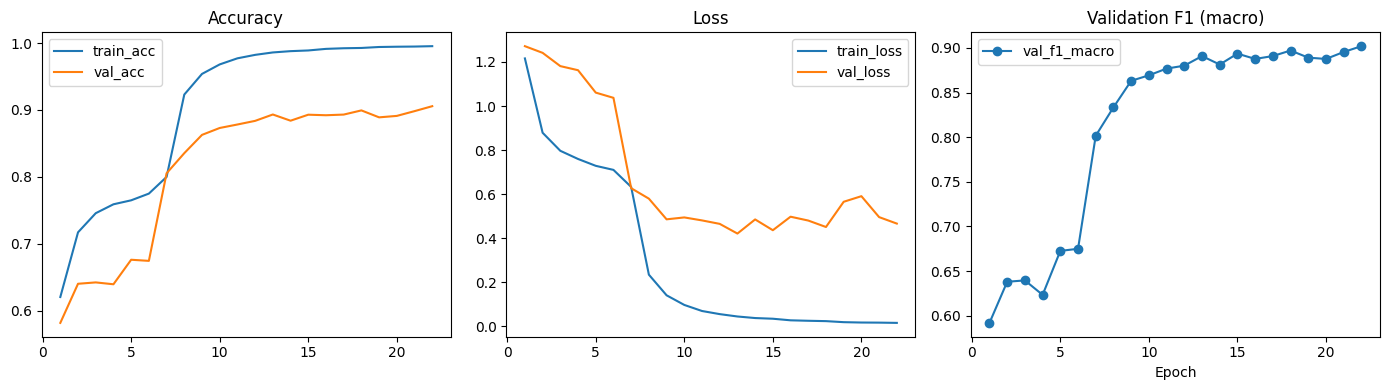

In [ ]:
# combine histories
def combine_histories(h1, h2):
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history.get(k, [])
    for k in h2.history:
        if k not in history:
            history[k] = h2.history[k]
    return history

combined_hist = combine_histories(history1, history2)
f1_all = (f1_callback.f1s if hasattr(f1_callback, 'f1s') else []) + (f1_callback2.f1s if hasattr(f1_callback2, 'f1s') else [])

# accuracy & loss
epochs_range = range(1, len(combined_hist['accuracy']) + 1)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(epochs_range, combined_hist['accuracy'], label='train_acc')
plt.plot(epochs_range, combined_hist['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,3,2)
plt.plot(epochs_range, combined_hist['loss'], label='train_loss')
plt.plot(epochs_range, combined_hist['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(range(1, 1+len(f1_all)), f1_all, marker='o', label='val_f1_macro')
plt.title('Validation F1 (macro)')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


### Predict on validation set and show classification report + confusion matrix

1013/1013 ━━━━━━━━━━━━━━━━━━━━ 183s 180ms/step
Classification report (validation):
              precision    recall  f1-score   support

           A     0.9636    0.9700    0.9668       600
           B     0.9319    0.9800    0.9553       600
           C     0.9724    0.9967    0.9844       600
           D     0.9534    0.9883    0.9705       600
           E     0.8593    0.9667    0.9098       600
           F     0.9868    1.0000    0.9934       600
           G     0.9620    0.8867    0.9228       600
           H     0.8904    0.9883    0.9368       600
           I     0.9938    0.8067    0.8905       600
           J     0.9529    0.8433    0.8948       600
           K     0.9892    0.9150    0.9506       600
           L     0.9315    0.9967    0.9630       600
           M     0.8662    0.9817    0.9203       600
           N     0.9053    0.8600    0.8821       600
           O     0.9845    0.8483    0.9114       600
           P     0.9613    0.8700    0.9134       60

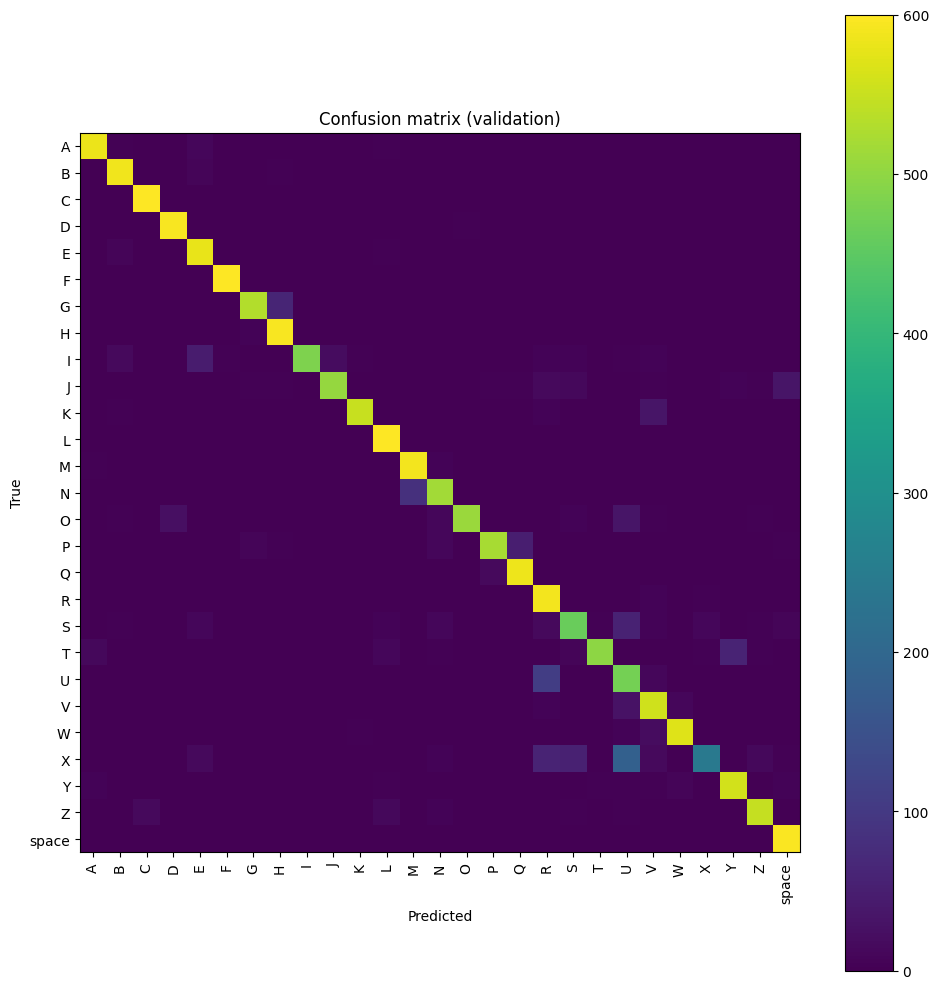

In [ ]:
# Ensure generator shuffle=False for correct ordering
val_preds_prob = model.predict(validation_generator, verbose=1)
val_preds = np.argmax(val_preds_prob, axis=1)
val_true  = validation_generator.classes
class_labels = list(train_generator.class_indices.keys())

print("Classification report (validation):")
print(classification_report(val_true, val_preds, target_names=class_labels, digits=4))

cm = confusion_matrix(val_true, val_preds)
plt.figure(figsize=(10,10))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion matrix (validation)")
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(ticks=np.arange(len(class_labels)), labels=class_labels, rotation=90)
plt.yticks(ticks=np.arange(len(class_labels)), labels=class_labels)
plt.tight_layout()
plt.show()


### Save model and class indices

In [ ]:
# Saving the model
model.save("asl_inception_final.h5")
print("Saved model to asl_inception_final.h5")

# Save class indices mapping
with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)
print("Saved class indices to class_indices.json")


Saved model to asl_inception_final.h5
Saved class indices to class_indices.json


### <b>TEST CASE: </b> Predict on 3 random images from test folder (display them)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


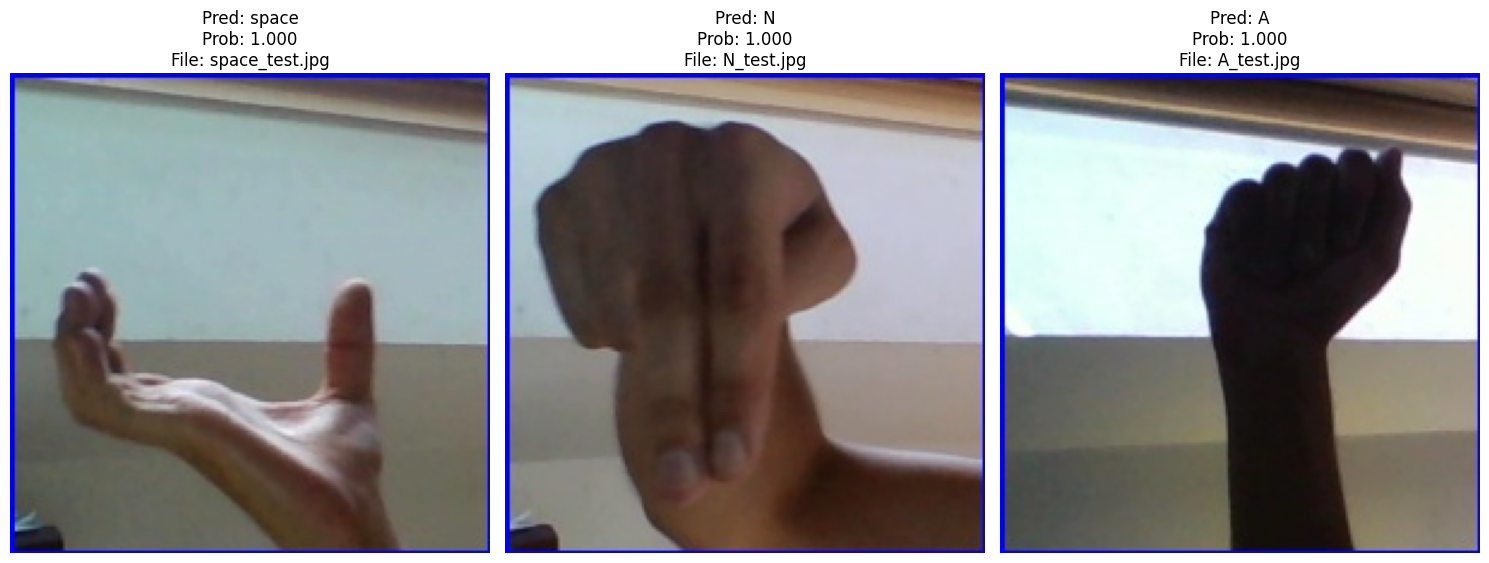

In [ ]:
import glob
from tensorflow.keras.preprocessing import image

# gather all image file paths from TEST_DIR
img_paths = []
for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_paths.append(os.path.join(root, file))

if len(img_paths) == 0:
    raise RuntimeError("No test images found in TEST_DIR. Check TEST_DIR path.")

random.seed(SEED)
sample_paths = random.sample(img_paths, k=min(3, len(img_paths)))

plt.figure(figsize=(15,6))
for i, p in enumerate(sample_paths):
    img = image.load_img(p, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)  # same preprocessing used for training
    preds = model.predict(x)[0]
    top_idx = np.argmax(preds)
    top_prob = preds[top_idx]
    pred_class = class_labels[top_idx]

    plt.subplot(1,3,i+1)
    plt.imshow((image.load_img(p)).convert('RGB'))
    plt.title(f"Pred: {pred_class}\nProb: {top_prob:.3f}\nFile: {os.path.basename(p)}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### <b>TEST CASE: </b> Load model + create single-image prediction function

In [ ]:
# Load model
model = tf.keras.models.load_model("asl_inception_final.h5")

# Load class label mapping (class → index)
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

# Reverse mapping (index → class)
index_to_class = {v: k for k, v in class_indices.items()}

IMG_SIZE = (224, 224)   # or (299, 299) if you used that


def predict_sign(img_path):
    """
    Predicts the ASL sign from a single image path.
    """

    # Load the image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    x = image.img_to_array(img)

    # Expand and preprocess
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)[0]
    idx = np.argmax(preds)
    confidence = preds[idx]

    predicted_class = index_to_class[idx]
    
    return predicted_class, confidence


In [ ]:
img_path = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train/Y/Y1024.jpg"  # change to your image!
pred, prob = predict_sign(img_path)

print(f"Predicted letter: {pred}")
print(f"Confidence: {prob:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted letter: Y
Confidence: 1.0000


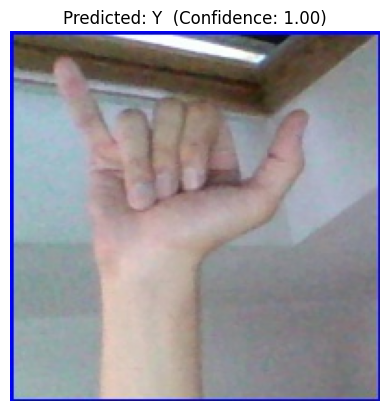

In [ ]:
img = mpimg.imread(img_path)

plt.imshow(img)
plt.title(f"Predicted: {pred}  (Confidence: {prob:.2f})")
plt.axis('off')
plt.show()
